# 📊 Handling Outliers (Clipping, Winsorization, and Removal)

## Outliers 
are extremely large or small values that are very different from the rest of the dataset.

Example:
* Normal sales values → `100, 200, 300`
* Outlier values → `5000, 3000`

Outliers can:
* Distort averages and statistics
* Affect machine learning models
* Create misleading visualizations

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats.mstats import winsorize

In [2]:
df = pd.DataFrame({
    "sales": [100, 200, 150, 300, 5000, 700, 3000, 1500, 400, 600]
})

df

,sales
0,100
1,200
2,150
3,300
4,5000
5,700
6,3000
7,1500
8,400
9,600


- Values like: 5000, 3000, 1500 are much larger than other values and may act as outliers.

In [3]:
df.describe()

,sales
count,10.000000
mean,1195.000000
std,1603.546417
min,100.000000
25%,225.000000
50%,500.000000
75%,1300.000000
max,5000.000000


- The mean becomes very large because of outliers.
- Without outliers, the average sales would be much smaller.

### Boxplot of Sales (Outliers Visible)

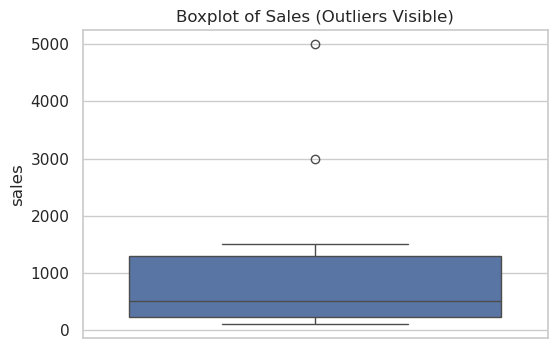

In [4]:
sns.set(style="whitegrid")

plt.figure(figsize=(6,4))
sns.boxplot(y=df["sales"])

plt.title("Boxplot of Sales (Outliers Visible)")
plt.savefig("Boxplot of Sales (Outliers Visible)",dpi=100)
plt.show()

- Values like: 5000, 3000 appear far away from other values, showing they are outliers.

### Method 1 - Clipping Outliers
- Clipping limits values to a fixed boundary.
- If a value exceeds the boundary it is replaced with the boundary value.
- Clipping is useful when you want to reduce extreme values but do not want to remove data completely
- `clip(upper=1000)`: Any value greater than `1000` becomes `1000`.

In [5]:
# Apply Clipping
df['sales_clipped'] = df['sales'].clip(upper=1000)
df

,sales,sales_clipped
0,100,100
1,200,200
2,150,150
3,300,300
4,5000,1000
5,700,700
6,3000,1000
7,1500,1000
8,400,400
9,600,600


#### Visualize Clipped Data

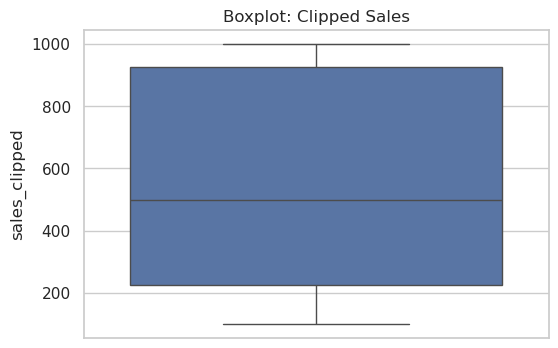

In [6]:
plt.figure(figsize=(6,4))

sns.boxplot(y=df["sales_clipped"])

plt.title("Boxplot: Clipped Sales")
plt.savefig("Boxplot: Clipped Sales",dpi=100)
plt.show()

After clipping:
 * extreme values are controlled
 * distribution becomes more balanced
 * boxplot looks cleaner

### Method 2 - Winsorization

Winsorization replaces extreme values using percentile limits instead of fixed manual thresholds. Winsorization preserves dataset size, reduces outlier effect and is better than deleting rows in many ML tasks
- `limits=[0, 0.2]`:
 - Lower 0% values remain unchanged
 - Upper 20% extreme values are replaced
 - Since upper 20% of 10 values = top 2 values: 5000, 3000 will be replaced by the next highest acceptable value.

In [7]:
# Apply Winsorization

df['sales_winsor'] = winsorize(df['sales'], limits=[0, 0.2])
df

,sales,sales_clipped,sales_winsor
0,100,100,100
1,200,200,200
2,150,150,150
3,300,300,300
4,5000,1000,1500
5,700,700,700
6,3000,1000,1500
7,1500,1000,1500
8,400,400,400
9,600,600,600


### Method 3 - Removing Outliers
Instead of modifying extreme values, we completely remove them.
- where(condition, replacement): Keep values satisfying the condition and Replace others with `NaN

In [8]:
# Replace Outliers with NaN
df['sales_removed'] = df['sales'].where(df['sales'] <= 1000, np.nan)
df

,sales,sales_clipped,sales_winsor,sales_removed
0,100,100,100,100.0
1,200,200,200,200.0
2,150,150,150,150.0
3,300,300,300,300.0
4,5000,1000,1500,NaN
5,700,700,700,700.0
6,3000,1000,1500,NaN
7,1500,1000,1500,NaN
8,400,400,400,400.0
9,600,600,600,600.0


In [9]:
df['sales'] <= 1000

0     True
1     True
2     True
3     True
4    False
5     True
6    False
7    False
8     True
9     True
Name: sales, dtype: bool

- values above `1000` become `NaN`

### Comparison of Methods Using Boxplot

| Method        | Description                  | Keeps Data? | Modifies Values? | Situation                 |
| ------------- | ---------------------------- | ----------- | ---------------- |------------------------- |
| Original      | Raw dataset                  | ✅ Yes       | ❌ No            |
| Clipping      | Caps values at threshold     | ✅ Yes       | ✅ Yes           | Quick normalization & Preserve all rows |
| Winsorization | Replaces extreme percentiles | ✅ Yes       | ✅ Yes           | ML preprocessing & Preserve all rows    |
| Removal       | Deletes extreme values       | ❌ No        | ❌ Removes rows  | Extreme values are errors               |

A **boxplot** helps identify outliers visually. A boxplot contains:

* **Box**
  → Represents the middle 50% of data

* **Line inside box**
  → Median value

* **Whiskers**
  → Range of normal values

* **Dots outside whiskers**
  → Potential outliers


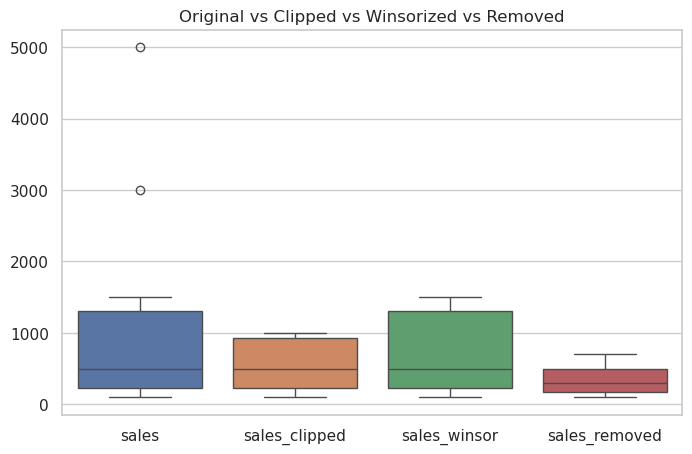

In [10]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df[
    ["sales",
     "sales_clipped",
     "sales_winsor",
     "sales_removed"]
])

plt.title(
    "Original vs Clipped vs Winsorized vs Removed"
)
plt.savefig("Original vs Clipped vs Winsorized vs Removed",dpi=100)
plt.show()

## Conclusion
* Outliers can heavily affect analysis
* Boxplots help detect outliers visually
* Clipping caps extreme values
* Winsorization smooths extreme values statistically
* Removal deletes extreme observations
* Different problems require different strategies